<a href="https://colab.research.google.com/github/hannahb15/STAT-499-STUDY/blob/main/STAT_499_ASHLEY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import statsmodels.api as sm

# Load data
df = pd.read_csv("mental_health_diagnosis_treatment_.csv")
df.head()

,Patient ID,Age,Gender,Diagnosis,Symptom Severity (1-10),Mood Score (1-10),Sleep Quality (1-10),Physical Activity (hrs/week),Medication,Therapy Type,Treatment Start Date,Treatment Duration (weeks),Stress Level (1-10),Outcome,Treatment Progress (1-10),AI-Detected Emotional State,Adherence to Treatment (%)
0,1,43,Female,Major Depressive Disorder,10,5,8,5,Mood Stabilizers,Interpersonal Therapy,2024-01-25,11,9,Deteriorated,7,Anxious,66
1,2,40,Female,Major Depressive Disorder,9,5,4,7,Antipsychotics,Interpersonal Therapy,2024-02-27,11,7,No Change,7,Neutral,78
2,3,55,Female,Major Depressive Disorder,6,3,4,3,SSRIs,Mindfulness-Based Therapy,2024-03-20,14,7,Deteriorated,5,Happy,62
3,4,34,Female,Major Depressive Disorder,6,3,6,5,SSRIs,Mindfulness-Based Therapy,2024-03-29,8,8,Deteriorated,10,Excited,72
4,5,52,Male,Panic Disorder,7,6,6,8,Anxiolytics,Interpersonal Therapy,2024-03-18,12,5,Deteriorated,6,Excited,63


In [6]:
# Select relevant columns
focus2 = df[["AI-Detected Emotional State", "Outcome"]].copy()

# Clean data
focus2 = focus2.dropna()
focus2["AI-Detected Emotional State"] = focus2["AI-Detected Emotional State"].astype(str).str.strip()
focus2["Outcome"] = focus2["Outcome"].astype(str).str.strip()

# Check counts
print(focus2["AI-Detected Emotional State"].value_counts())
print()
print(focus2["Outcome"].value_counts())

AI-Detected Emotional State
Anxious      102
Neutral       87
Excited       85
Stressed      79
Happy         78
Depressed     69
Name: count, dtype: int64

Outcome
Deteriorated    171
Improved        170
No Change       159
Name: count, dtype: int64


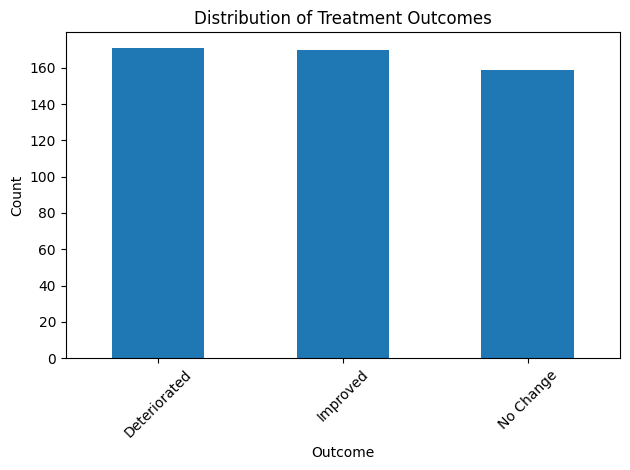

In [7]:
# Plot outcome distribution
focus2["Outcome"].value_counts().plot(kind="bar")
plt.title("Distribution of Treatment Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

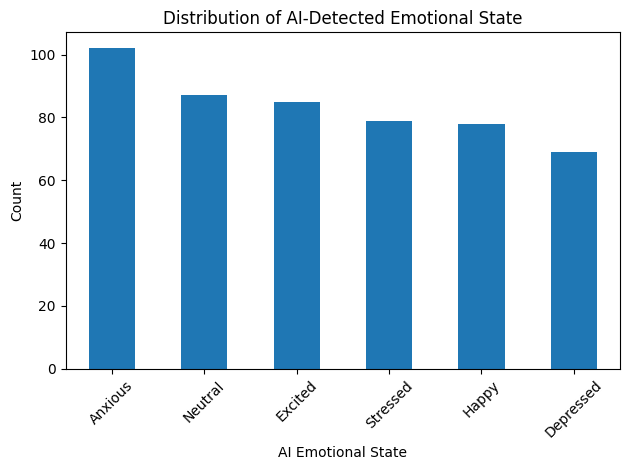

In [8]:
# Plot emotional state distribution
focus2["AI-Detected Emotional State"].value_counts().plot(kind="bar")
plt.title("Distribution of AI-Detected Emotional State")
plt.xlabel("AI Emotional State")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# Crosstab and row percentages
table = pd.crosstab(focus2["AI-Detected Emotional State"], focus2["Outcome"])
print(table)

row_percent = pd.crosstab(focus2["AI-Detected Emotional State"], focus2["Outcome"], normalize="index") * 100
print(round(row_percent, 2))

Outcome                      Deteriorated  Improved  No Change
AI-Detected Emotional State                                   
Anxious                                36        28         38
Depressed                              28        23         18
Excited                                27        30         28
Happy                                  27        28         23
Neutral                                31        33         23
Stressed                               22        28         29
Outcome                      Deteriorated  Improved  No Change
AI-Detected Emotional State                                   
Anxious                             35.29     27.45      37.25
Depressed                           40.58     33.33      26.09
Excited                             31.76     35.29      32.94
Happy                               34.62     35.90      29.49
Neutral                             35.63     37.93      26.44
Stressed                            27.85     35.44    

In [10]:
# Chi-square test
chi2, p, dof, expected = chi2_contingency(table)
print("Chi-square:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)

Chi-square: 7.070555289958452
Degrees of freedom: 10
p-value: 0.7187677386197544


In [11]:
# Multinomial logistic regression
X = pd.get_dummies(focus2["AI-Detected Emotional State"], drop_first=True).astype(int)
X = sm.add_constant(X)
y = focus2["Outcome"].astype("category")

model = sm.MNLogit(y.cat.codes, X)
result = model.fit()
print(result.summary())
print(dict(enumerate(y.cat.categories)))

Optimization terminated successfully.
         Current function value: 1.090892
         Iterations 4
                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                  500
Model:                        MNLogit   Df Residuals:                      488
Method:                           MLE   Df Model:                           10
Date:                Tue, 07 Apr 2026   Pseudo R-squ.:                0.006542
Time:                        07:11:34   Log-Likelihood:                -545.45
converged:                       True   LL-Null:                       -549.04
Covariance Type:            nonrobust   LLR p-value:                    0.7080
       y=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2513      0.252     -0.997      0.319      -0.745       0.243
Depressed      0.0546      0.